## Types of Gradient Descents

In [1]:
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
# Generate data
X, y = make_moons(n_samples=1500, noise=0.22, random_state=SEED)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 1200
Test samples: 300


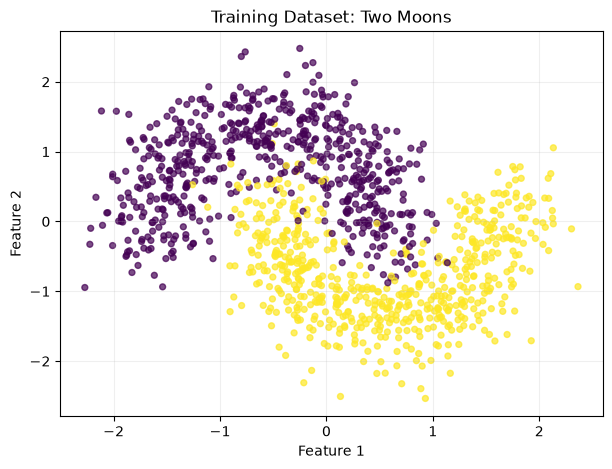

In [4]:
plt.figure(figsize=(7, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=18, alpha=0.7)
plt.title("Training Dataset: Two Moons")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(alpha=0.2)
plt.show()

In [5]:
def build_model(learning_rate=0.05, seed=SEED):
    # Reset random state so every experiment starts from the same initial weights
    tf.keras.utils.set_random_seed(seed)

    model = keras.Sequential([
        layers.Input(shape=(2,)),
        layers.Dense(16, activation="relu"),
        layers.Dense(8, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])

    optimizer = keras.optimizers.SGD(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Show architecture once
example_model = build_model()
example_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
EPOCHS = 50
LEARNING_RATE = 0.05

def train_experiment(name, batch_size):
    model = build_model(learning_rate=LEARNING_RATE)

    start = time.perf_counter()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=EPOCHS,
        batch_size=batch_size,
        shuffle=True,
        verbose=0
    )
    elapsed = time.perf_counter() - start

    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

    updates_per_epoch = int(np.ceil(len(X_train) / batch_size))

    return {
        "name": name,
        "model": model,
        "history": history,
        "batch_size": batch_size,
        "updates_per_epoch": updates_per_epoch,
        "time_seconds": elapsed,
        "test_loss": test_loss,
        "test_accuracy": test_accuracy
    }

In [7]:
N = len(X_train)

experiments = [
    train_experiment("Batch GD", batch_size=N),
    train_experiment("Stochastic GD", batch_size=1),
    train_experiment("Mini-Batch GD", batch_size=32),
]

print("Training complete.")

Training complete.


In [8]:
results = pd.DataFrame([
    {
        "Method": exp["name"],
        "Batch Size": exp["batch_size"],
        "Updates / Epoch": exp["updates_per_epoch"],
        "Approx. Total Updates": exp["updates_per_epoch"] * EPOCHS,
        "Training Time (s)": exp["time_seconds"],
        "Test Loss": exp["test_loss"],
        "Test Accuracy": exp["test_accuracy"]
    }
    for exp in experiments
])

results.round(4)

,Method,Batch Size,Updates / Epoch,Approx. Total Updates,Training Time (s),Test Loss,Test Accuracy
0,Batch GD,1200,1,50,12.9376,0.4388,0.8367
1,Stochastic GD,1,1200,60000,243.5310,0.1334,0.9433
2,Mini-Batch GD,32,38,1900,15.3463,0.1349,0.9467


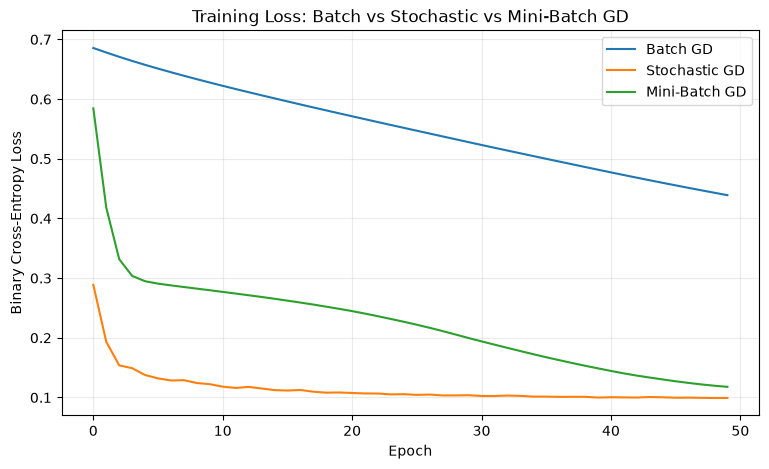

In [9]:
plt.figure(figsize=(9, 5))

for exp in experiments:
    plt.plot(exp["history"].history["loss"], label=exp["name"])

plt.title("Training Loss: Batch vs Stochastic vs Mini-Batch GD")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

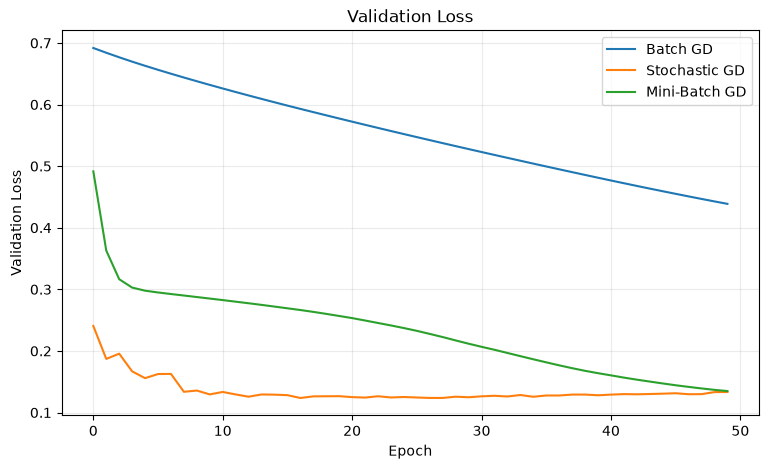

In [10]:
plt.figure(figsize=(9, 5))

for exp in experiments:
    plt.plot(exp["history"].history["val_loss"], label=exp["name"])

plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

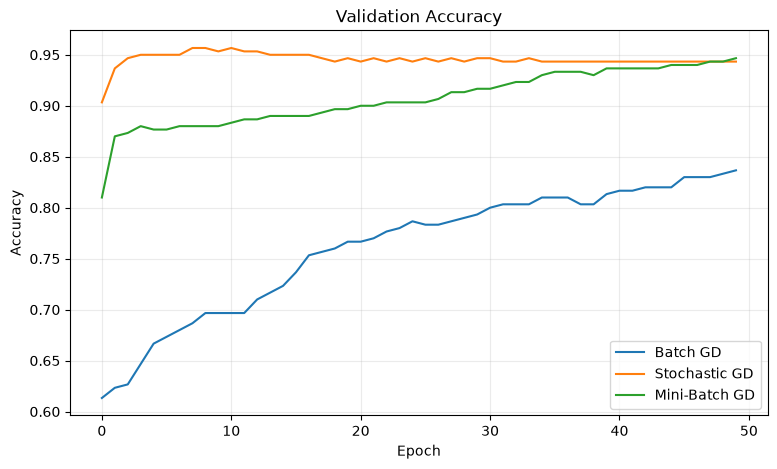

In [11]:
plt.figure(figsize=(9, 5))

for exp in experiments:
    plt.plot(exp["history"].history["val_accuracy"], label=exp["name"])

plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

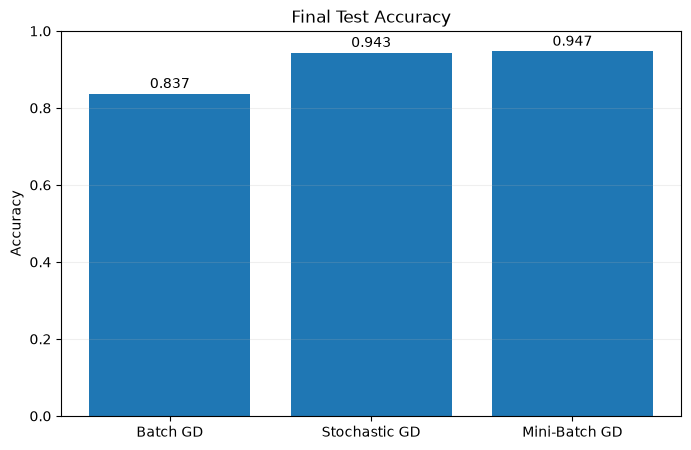

In [12]:
methods = [exp["name"] for exp in experiments]
accuracies = [exp["test_accuracy"] for exp in experiments]

plt.figure(figsize=(8, 5))
plt.bar(methods, accuracies)
plt.ylim(0, 1)
plt.title("Final Test Accuracy")
plt.ylabel("Accuracy")

for i, value in enumerate(accuracies):
    plt.text(i, value + 0.015, f"{value:.3f}", ha="center")

plt.grid(axis="y", alpha=0.2)
plt.show()

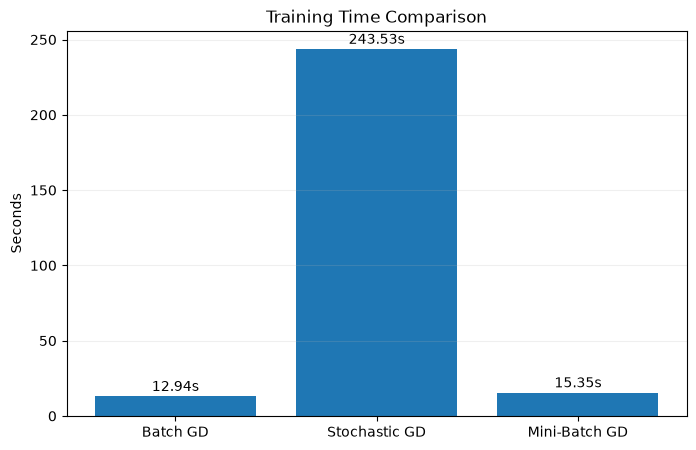

In [13]:
times = [exp["time_seconds"] for exp in experiments]

plt.figure(figsize=(8, 5))
plt.bar(methods, times)
plt.title("Training Time Comparison")
plt.ylabel("Seconds")

for i, value in enumerate(times):
    plt.text(i, value + max(times)*0.015, f"{value:.2f}s", ha="center")

plt.grid(axis="y", alpha=0.2)
plt.show()

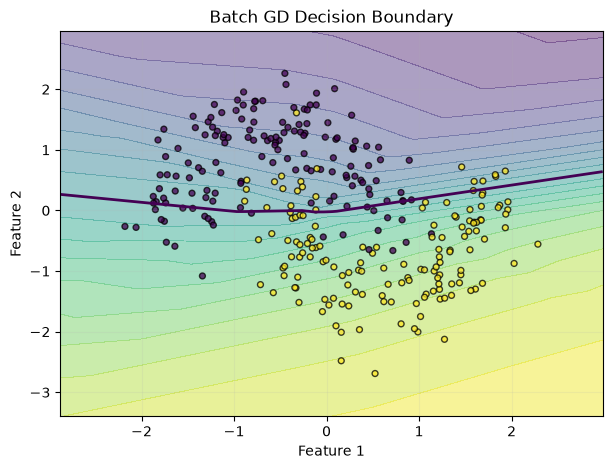

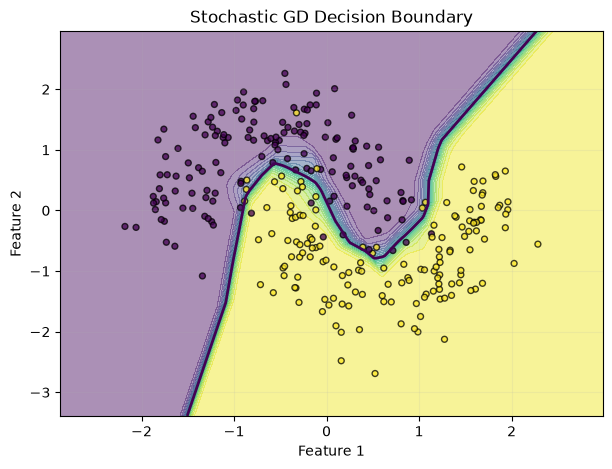

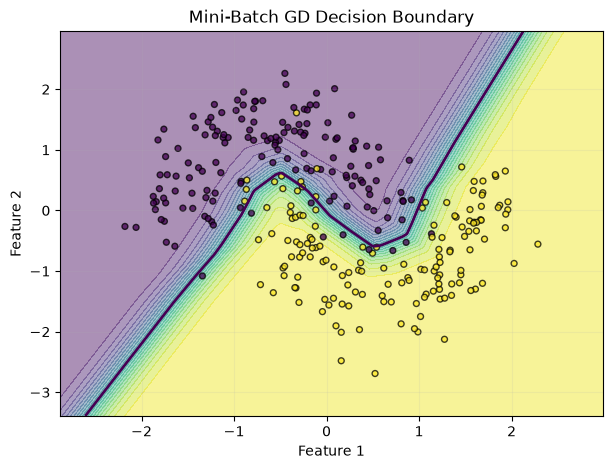

In [14]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.7, X[:, 0].max() + 0.7
    y_min, y_max = X[:, 1].min() - 0.7, X[:, 1].max() + 0.7

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 250),
        np.linspace(y_min, y_max, 250)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    probabilities = model.predict(grid, verbose=0).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, probabilities, levels=20, alpha=0.45)
    plt.contour(xx, yy, probabilities, levels=[0.5], linewidths=2)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=18, edgecolors="k", alpha=0.75)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(alpha=0.15)
    plt.show()

for exp in experiments:
    plot_decision_boundary(
        exp["model"], X_test, y_test,
        f'{exp["name"]} Decision Boundary'
    )

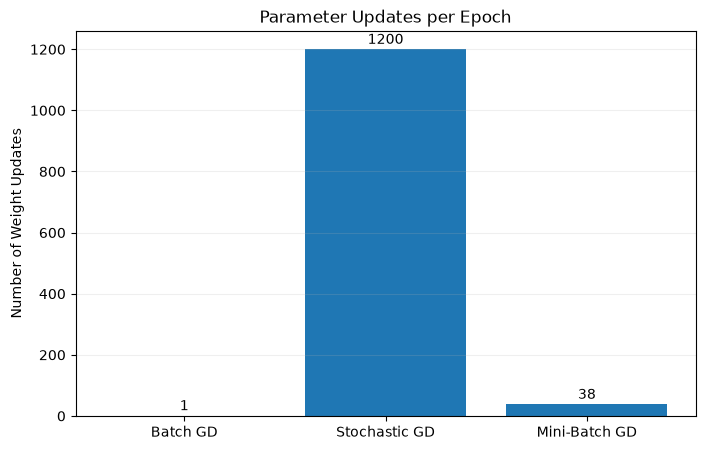

In [15]:
updates = [exp["updates_per_epoch"] for exp in experiments]

plt.figure(figsize=(8, 5))
plt.bar(methods, updates)
plt.title("Parameter Updates per Epoch")
plt.ylabel("Number of Weight Updates")

for i, value in enumerate(updates):
    plt.text(i, value + max(updates)*0.015, str(value), ha="center")

plt.grid(axis="y", alpha=0.2)
plt.show()